# Car Crash Detection with YOLOv8

This notebook trains a **YOLOv8 object detector** to identify car damage and crashes using a custom Roboflow dataset.

**Upgraded from:** YOLOv5 (ultralytics/yolov5)
**Upgraded to:** YOLOv8 (ultralytics) – same team, cleaner API, better accuracy

### Steps
1. Install dependencies
2. Connect to Roboflow and download the car damage dataset
3. Load a pretrained YOLOv8 model
4. Train on the custom dataset
5. Evaluate performance (metrics + plots)
6. Run inference on test images and video
7. Export the trained model

> **Before running:** Go to `Runtime → Change Runtime Type → GPU` to enable GPU acceleration.

## Step 1 — Install Dependencies

In [ ]:
# Install YOLOv8 (ultralytics package) and Roboflow SDK
!pip install ultralytics roboflow -q

# Import necessary libraries
import torch
from ultralytics import YOLO

# Confirm if a GPU is available, which significantly speeds up training
gpu_available = torch.cuda.is_available()
device_name = torch.cuda.get_device_name(0) if gpu_available else 'CPU (no GPU found)'

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {gpu_available}')
print(f'Device          : {device_name}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version : 2.10.0+cu128
GPU available   : True
Device          : Tesla T4


## Step 2 — Download the Car Damage Dataset from Roboflow

We pull the same dataset used in the original YOLOv5 notebook.
Roboflow exports it in **YOLOv8 format**, which includes:
- `train/`, `valid/`, `test/` image folders
- YOLO-format `.txt` label files
- A `data.yaml` config file that YOLOv8 reads automatically

In [ ]:
from roboflow import Roboflow

# --- Roboflow Dataset Configuration --- #
# Replace with your actual Roboflow API key, workspace, and project details
# (These values are often stored as environment variables or secrets in real-world projects)
ROBOFLOW_API_KEY      = 'Enter your roboflow api key'
ROBOFLOW_WORKSPACE    = 'Enter your workspace'
ROBOFLOW_PROJECT_NAME = 'Enter your project name'
ROBOFLOW_VERSION      = 1
EXPORT_FORMAT         = 'yolov8'   # Exporting in YOLOv8 format for compatibility

# Authenticate and download the dataset from Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT_NAME)
dataset = project.version(ROBOFLOW_VERSION).download(EXPORT_FORMAT)

# Construct the path to the dataset's data.yaml configuration file
DATASET_YAML_PATH = dataset.location + '/data.yaml'
print(f'Dataset downloaded to: {dataset.location}')
print(f'Config file path     : {DATASET_YAML_PATH}')

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 95.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to Car-Damage-Detection-1 in yolov8:: 100%|██████████| 36399/36399 [00:06<00:00, 5354.85it/s]


Dataset downloaded to: /content/Car-Damage-Detection-1
Config file path     : /content/Car-Damage-Detection-1/data.yaml


In [ ]:
# Import the YAML library to parse the dataset configuration file
import yaml

# Load the data.yaml file to inspect dataset details like class names and splits
with open(DATASET_YAML_PATH, 'r') as config_file:
    dataset_config = yaml.safe_load(config_file)

# Extract class names and the total number of classes
class_names       = dataset_config['names']
number_of_classes = dataset_config['nc']

print(f'Number of classes : {number_of_classes}')
print(f'Class names       : {class_names}')
print()
print('Full data.yaml configuration:')
print(yaml.dump(dataset_config, default_flow_style=False))

Number of classes : 22
Class names       : ['Front-Windscreen-Damage', 'Headlight-Damage', 'Major-Rear-Bumper-Dent', 'Rear-windscreen-Damage', 'RunningBoard-Dent', 'Sidemirror-Damage', 'Signlight-Damage', 'Taillight-Damage', 'bonnet-dent', 'doorouter-dent', 'doorouter-scratch', 'fender-dent', 'front-bumper-dent', 'front-bumper-scratch', 'medium-Bodypanel-Dent', 'paint-chip', 'paint-trace', 'pillar-dent', 'quaterpanel-dent', 'rear-bumper-dent', 'rear-bumper-scratch', 'roof-dent']

Full data.yaml:
names:
- Front-Windscreen-Damage
- Headlight-Damage
- Major-Rear-Bumper-Dent
- Rear-windscreen-Damage
- RunningBoard-Dent
- Sidemirror-Damage
- Signlight-Damage
- Taillight-Damage
- bonnet-dent
- doorouter-dent
- doorouter-scratch
- fender-dent
- front-bumper-dent
- front-bumper-scratch
- medium-Bodypanel-Dent
- paint-chip
- paint-trace
- pillar-dent
- quaterpanel-dent
- rear-bumper-dent
- rear-bumper-scratch
- roof-dent
nc: 22
roboflow:
  license: Public Domain
  project: car-damage-detection-

## Step 3 — Load Pretrained YOLOv8 Model

We start from **YOLOv8s** (small) pretrained on COCO — equivalent to YOLOv5s.
Transfer learning from COCO weights gives much faster convergence than training from scratch.


In [ ]:
PRETRAINED_MODEL_WEIGHTS = 'yolov8s.pt'   # Using the small (s) variant, which downloads automatically

# Initialize the YOLO model with pretrained COCO weights
model = YOLO(PRETRAINED_MODEL_WEIGHTS)

print(f'Model loaded     : {PRETRAINED_MODEL_WEIGHTS}')
print(f'Number of layers : {len(model.model.model)}')
print(f'Parameters       : {sum(p.numel() for p in model.parameters()):,}')

Model loaded     : yolov8s.pt
Number of layers : 23
Parameters       : 11,166,560


## Step 4 — Train the Model

YOLOv8 training is a single Python call — no manual YAML writing needed.
All training arguments are named clearly and passed directly.

**Key arguments:**
- `data` — path to `data.yaml`
- `epochs` — number of full passes over the training set
- `image_size` — input resolution (higher = more accurate, slower)
- `batch_size` — images per gradient step (-1 = auto-select for your GPU)
- `device` — `0` for first GPU, `cpu` for CPU
- `pretrained` — start from COCO weights (recommended)
- `project` / `run_name` — where results are saved

In [ ]:
# ── Training Hyperparameters ──────────────────────────────────────────
# Define the input image size for training (YOLOv8 standard is 640)
INPUT_IMAGE_SIZE   = 640    # pixels
# Define the batch size (images processed per gradient update). -1 lets YOLOv8 auto-tune.
BATCH_SIZE         = 16
# Number of full passes over the entire training dataset
NUMBER_OF_EPOCHS   = 20
# Specify the device for training: 0 for the first GPU, 'cpu' for CPU training
TRAINING_DEVICE    = 0
# Whether to start training from COCO pretrained weights (recommended for faster convergence)
USE_PRETRAINED     = True

# ── Output Paths ─────────────────────────────────────────────────────
# Define the base folder for saving training runs
RESULTS_PROJECT_FOLDER = 'car_crash_detection_runs'
# Define the specific name for this training run's results
TRAINING_RUN_NAME      = 'yolov8s_car_damage_v1'

print('Training configuration:')
print(f'  Input image size : {INPUT_IMAGE_SIZE}x{INPUT_IMAGE_SIZE}')
print(f'  Batch size       : {BATCH_SIZE}')
print(f'  Epochs           : {NUMBER_OF_EPOCHS}')
print(f'  Device           : GPU {TRAINING_DEVICE}')
print(f'  Pretrained       : {USE_PRETRAINED}')
print(f'  Output folder    : {RESULTS_PROJECT_FOLDER}/{TRAINING_RUN_NAME}')

Training configuration:
  Input image size : 640x640
  Batch size       : 16
  Epochs           : 20
  Device           : GPU 0
  Pretrained       : True
  Output folder    : car_crash_detection_runs/yolov8s_car_damage_v1


In [ ]:
%%time

# Start the model training process with the specified configurations
training_results = model.train(
    data       = DATASET_YAML_PATH,  # Path to the dataset configuration file
    epochs     = NUMBER_OF_EPOCHS,   # Number of training epochs
    imgsz      = INPUT_IMAGE_SIZE,   # Input image size
    batch      = BATCH_SIZE,         # Batch size
    device     = TRAINING_DEVICE,    # Training device (GPU or CPU)
    pretrained = USE_PRETRAINED,     # Use pretrained weights
    project    = RESULTS_PROJECT_FOLDER, # Project directory for saving results
    name       = TRAINING_RUN_NAME,  # Name of this specific training run
    exist_ok   = True,               # Allow overwriting existing run directories if they have the same name
)

print('
✅ Training complete!')
print(f'Results saved to: {RESULTS_PROJECT_FOLDER}/{TRAINING_RUN_NAME}')

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Damage-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_car_damage_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

## Step 5 — Evaluate Model Performance

YOLOv8 automatically saves:
- `results.png` — loss and metric curves over epochs
- `confusion_matrix.png` — per-class prediction accuracy
- `PR_curve.png` — Precision-Recall curve
- `val_batch*.jpg` — sample validation predictions

We also run `model.val()` for a clean validation pass with final metrics.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Training curves (loss + mAP over epochs):


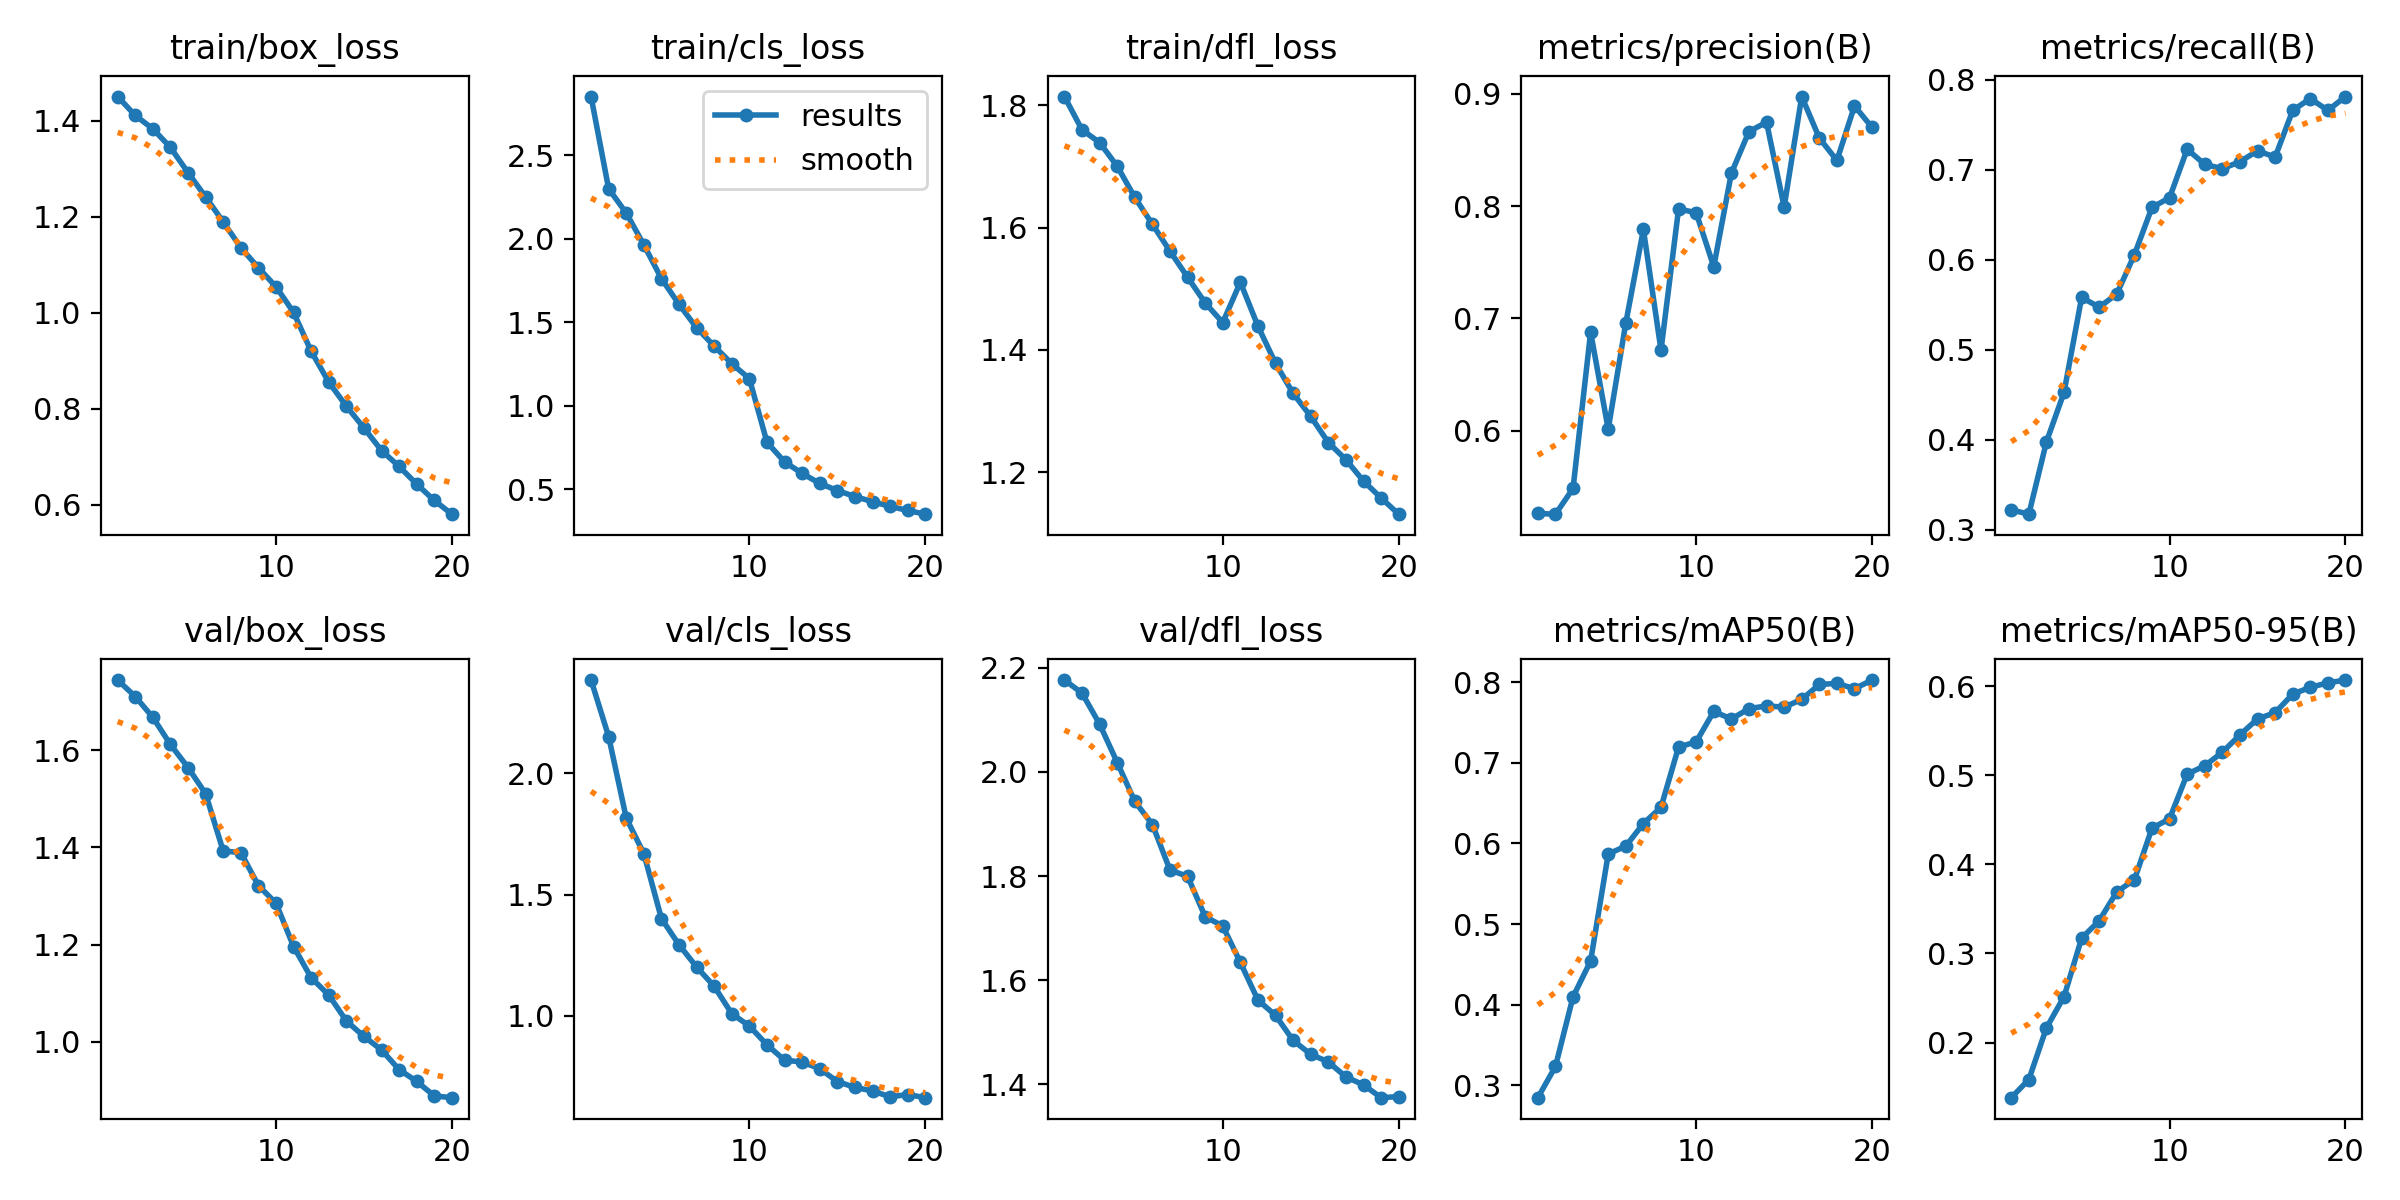

In [ ]:
import os
from IPython.display import Image, display

# Define the full path where training output (including plots) is saved
TRAINING_OUTPUT_FOLDER = f'/content/runs/detect/{RESULTS_PROJECT_FOLDER}/{TRAINING_RUN_NAME}'

# Display the training curves (loss and mAP over epochs)
training_curves_path = os.path.join(TRAINING_OUTPUT_FOLDER, 'results.png')
print('Loss and mAP curves during training:')
display(Image(filename=training_curves_path, width=1000))

Confusion matrix:


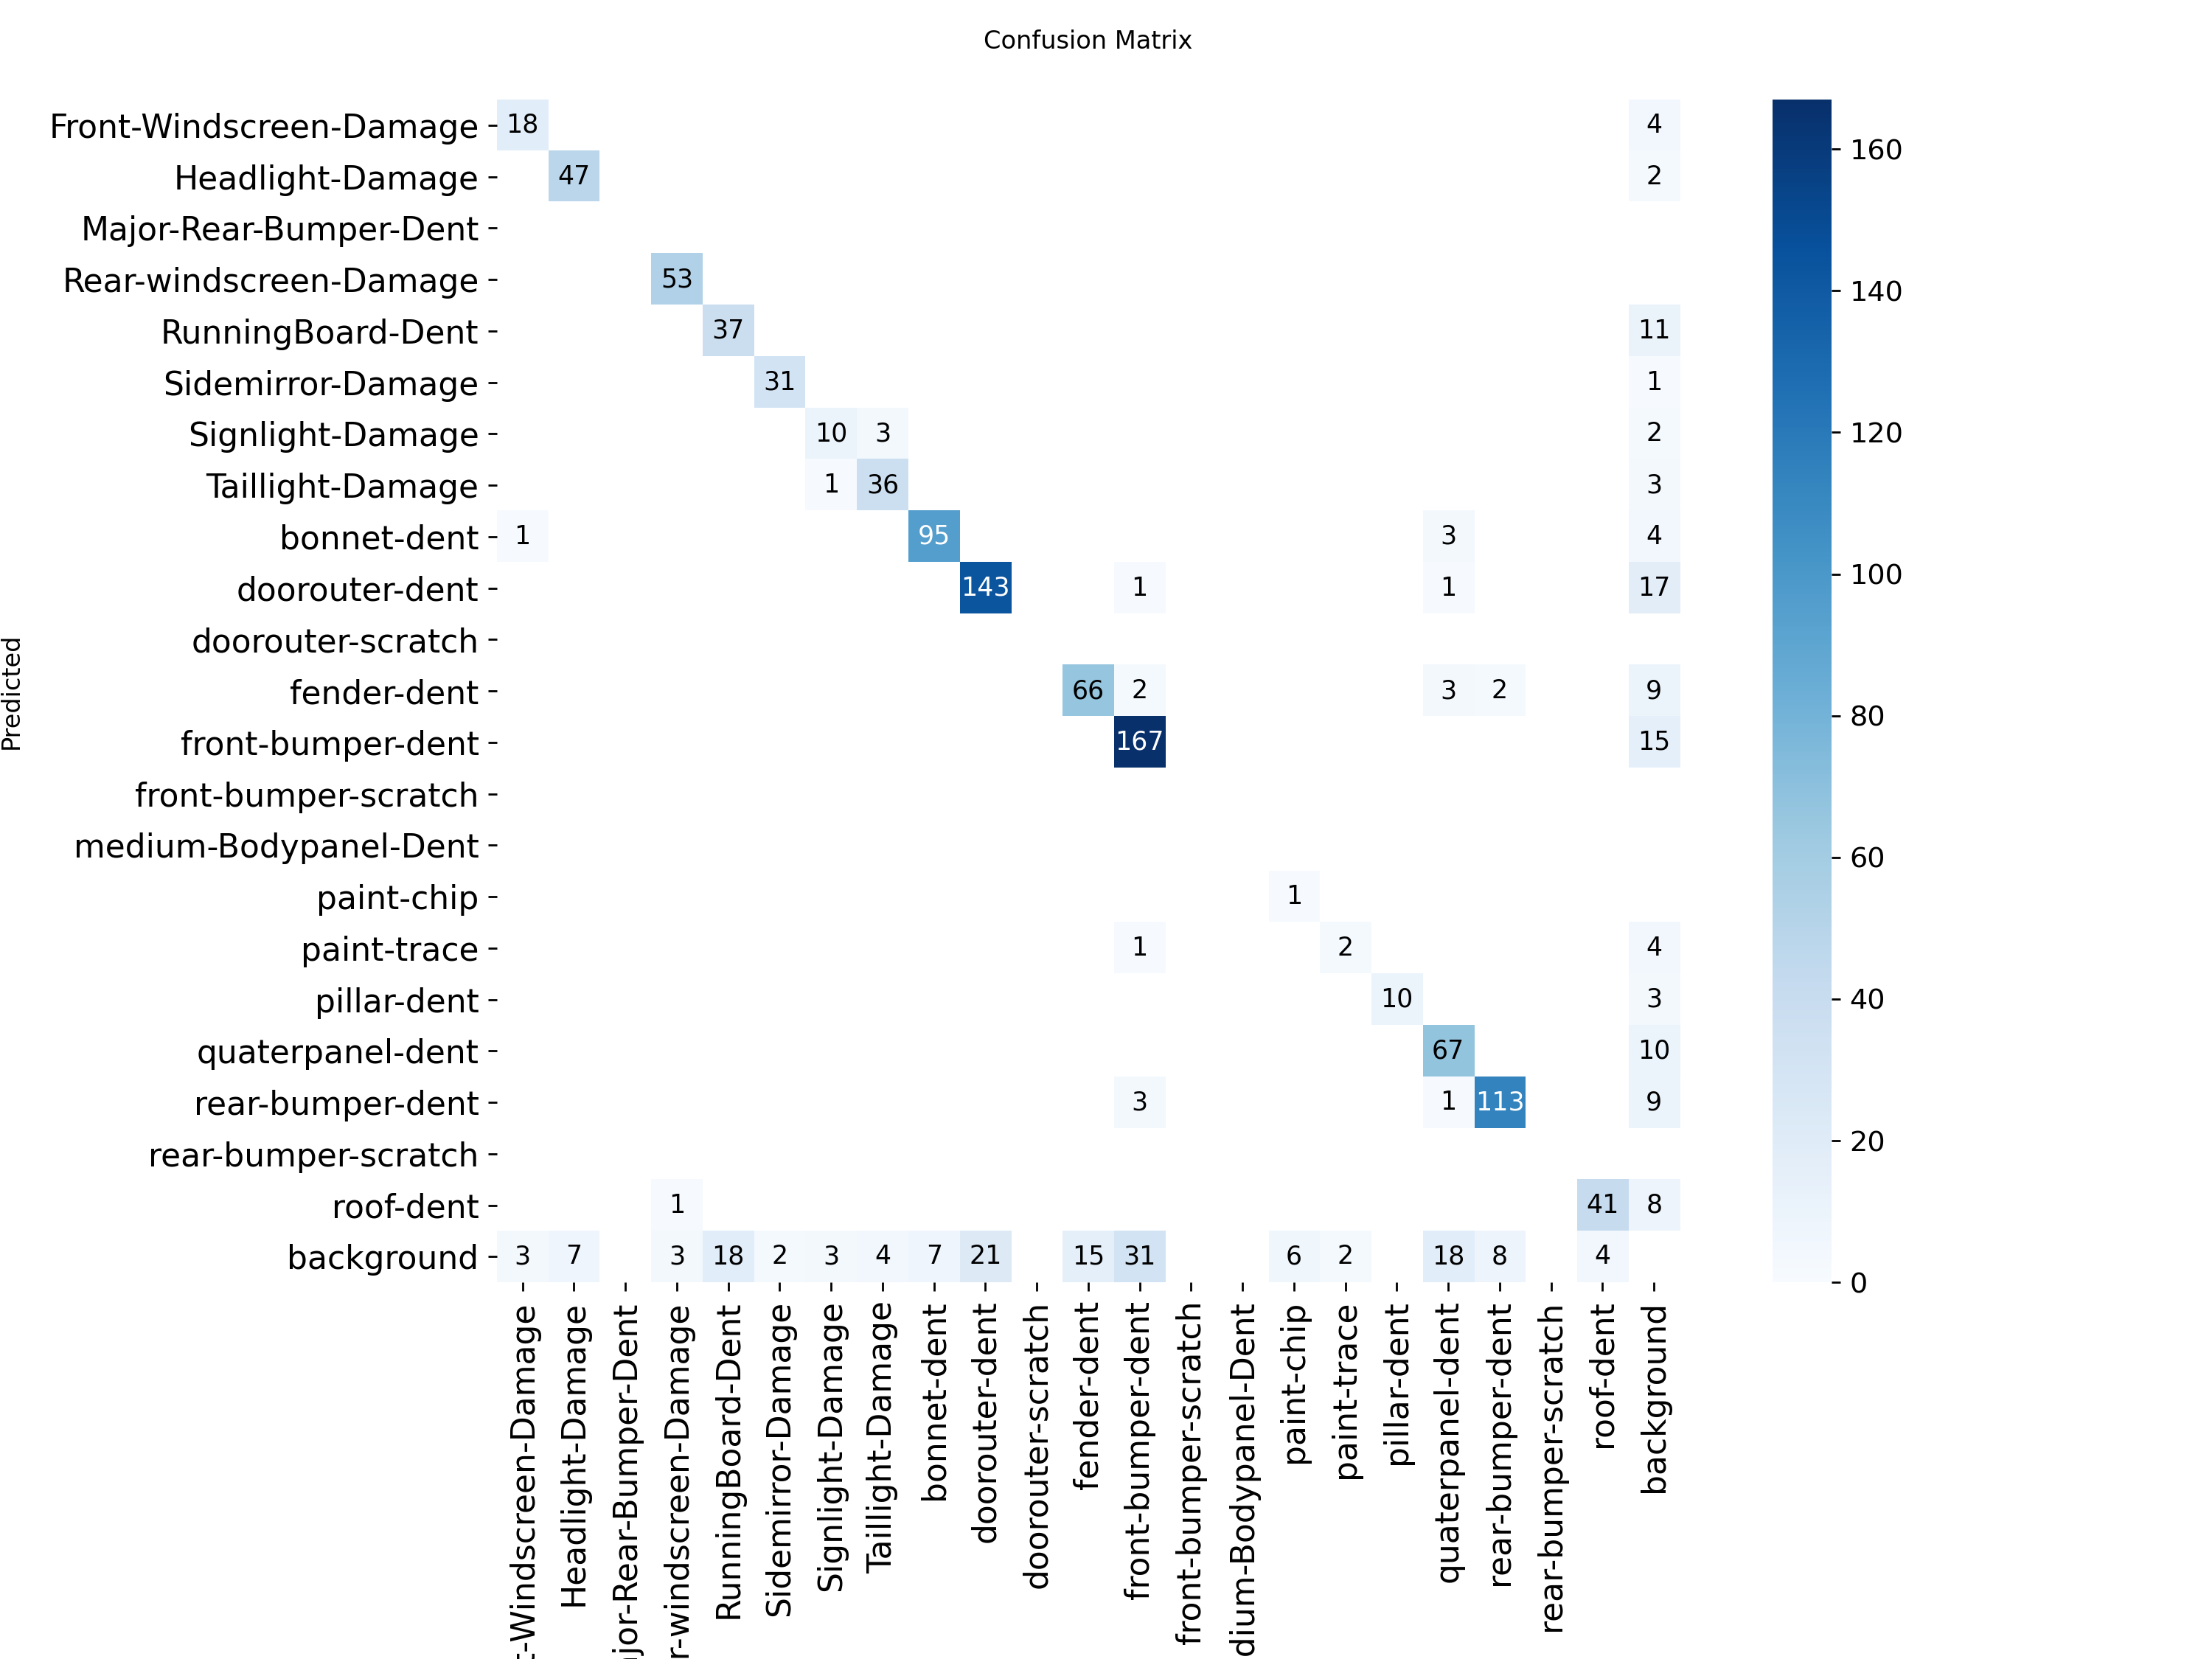

In [ ]:
# Display the confusion matrix, showing how well the model classified each damage type
confusion_matrix_path = os.path.join(TRAINING_OUTPUT_FOLDER, 'confusion_matrix.png')
print('Confusion matrix for object detection:')
display(Image(filename=confusion_matrix_path, width=800))

In [ ]:
# Note: PR_curve.png might not always be generated by default in all YOLOv8 training setups.
# If it were generated, we would display it here to show the precision-recall tradeoff.
print('PR_curve.png not found in the output directory. It might not have been generated during this training run.')

PR_curve.png not found in the output directory. It might not have been generated during this training run.


In [ ]:
# Construct the path to the best trained weights saved during the training process
TRAINED_WEIGHTS_PATH = os.path.join(TRAINING_OUTPUT_FOLDER, 'weights', 'best.pt')

# Load the best performing model checkpoint for validation
best_model = YOLO(TRAINED_WEIGHTS_PATH)

# Run a clean validation pass on the validation split of the dataset
# This calculates final performance metrics like mAP, Precision, and Recall
validation_metrics = best_model.val(
    data   = DATASET_YAML_PATH,  # Path to the dataset configuration
    imgsz  = INPUT_IMAGE_SIZE,   # Image size for validation
    device = TRAINING_DEVICE,    # Device to run validation on
)

print(f'\n📊 Validation Results:')
print(f'  Mean Average Precision (mAP@50)       : {validation_metrics.box.map50:.4f}')
print(f'  Mean Average Precision (mAP@50-95)    : {validation_metrics.box.map:.4f}')
print(f'  Overall Precision                     : {validation_metrics.box.mp:.4f}')
print(f'  Overall Recall                        : {validation_metrics.box.mr:.4f}')

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,134,098 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1457.4±431.1 MB/s, size: 37.9 KB)
val: Scanning /content/Car-Damage-Detection-1/valid/labels.cache... 773 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 773/773 270.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.4it/s 14.3s
                   all        773       1112       0.87      0.782      0.803      0.606
Front-Windscreen-Damage         22         22      0.863      0.818      0.861      0.662
      Headlight-Damage         54         54      0.959       0.87      0.883      0.661
Rear-windscreen-Damage         57         57      0.972      0.912      0.912      0.771
     RunningBoard-Dent         46         55      0.831      0.636      0.701      0.467
     Sidemirror-Damage       

Sample validation batch — ground truth labels:


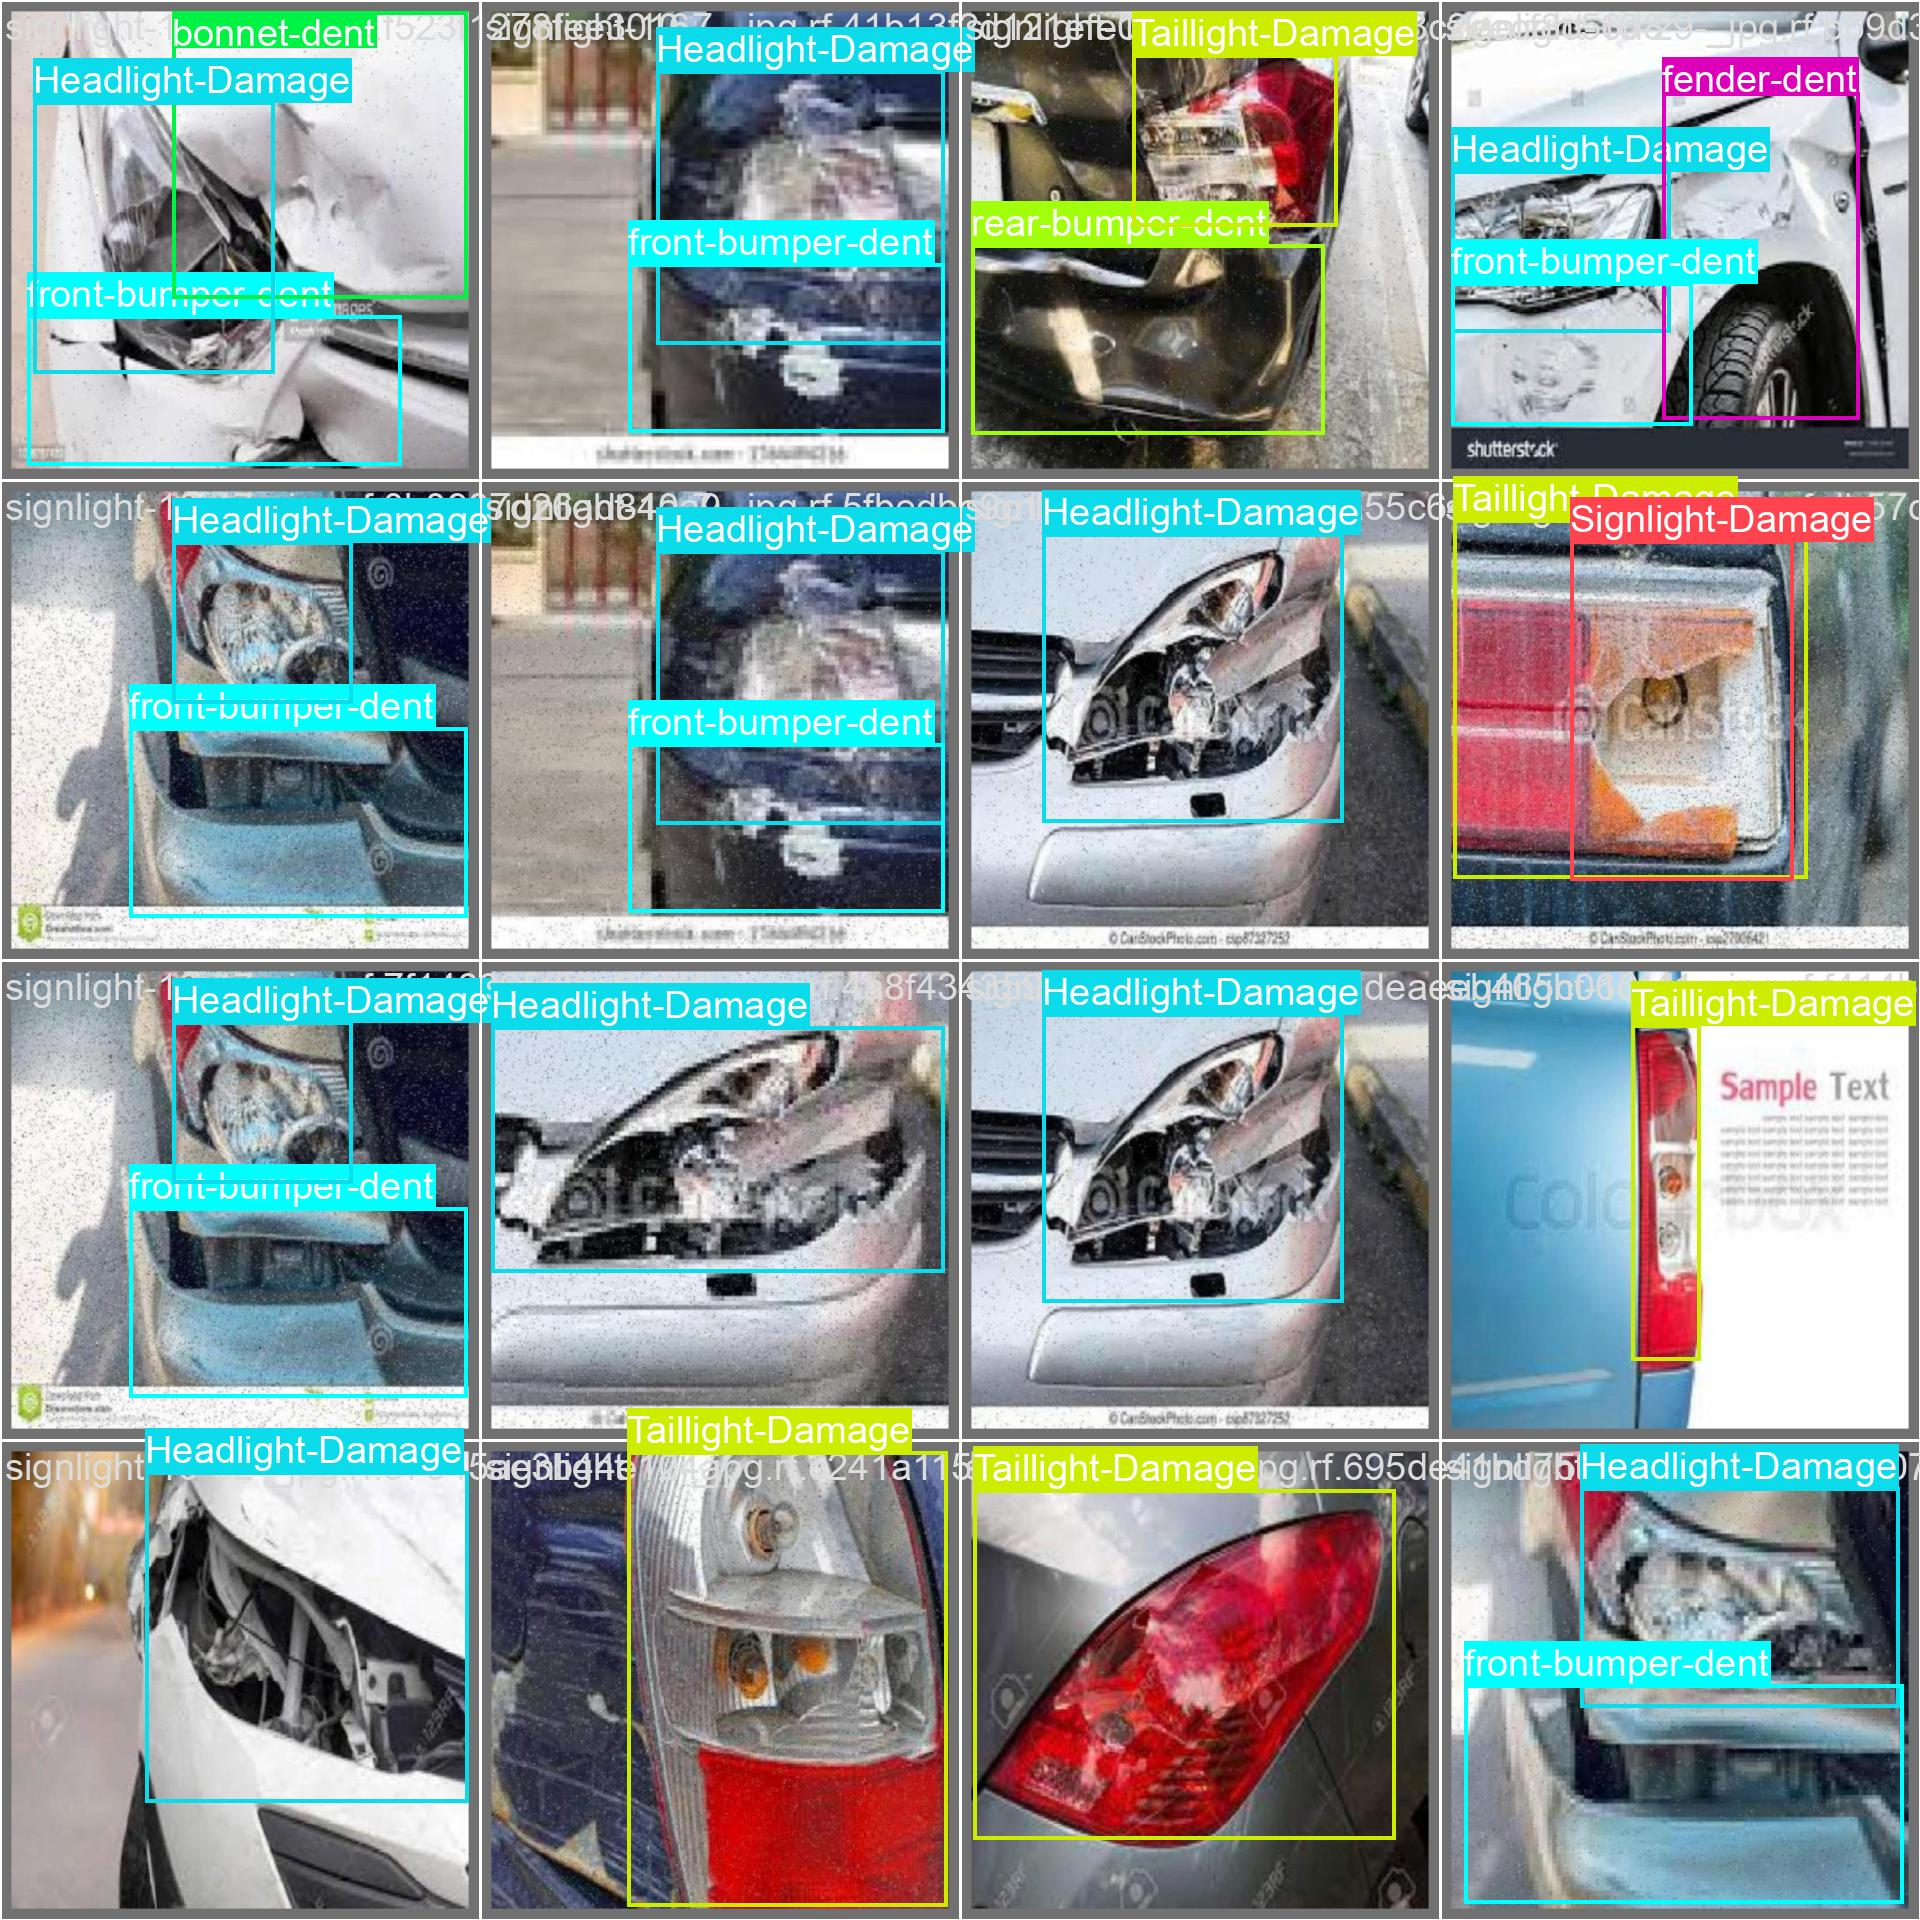

In [ ]:
# Display a sample batch of validation images with their ground truth labels
val_labels_preview_path = os.path.join(TRAINING_OUTPUT_FOLDER, 'val_batch0_labels.jpg')
print('Sample validation batch (ground truth labels):')
display(Image(filename=val_labels_preview_path, width=900))

Sample validation batch — model predictions:


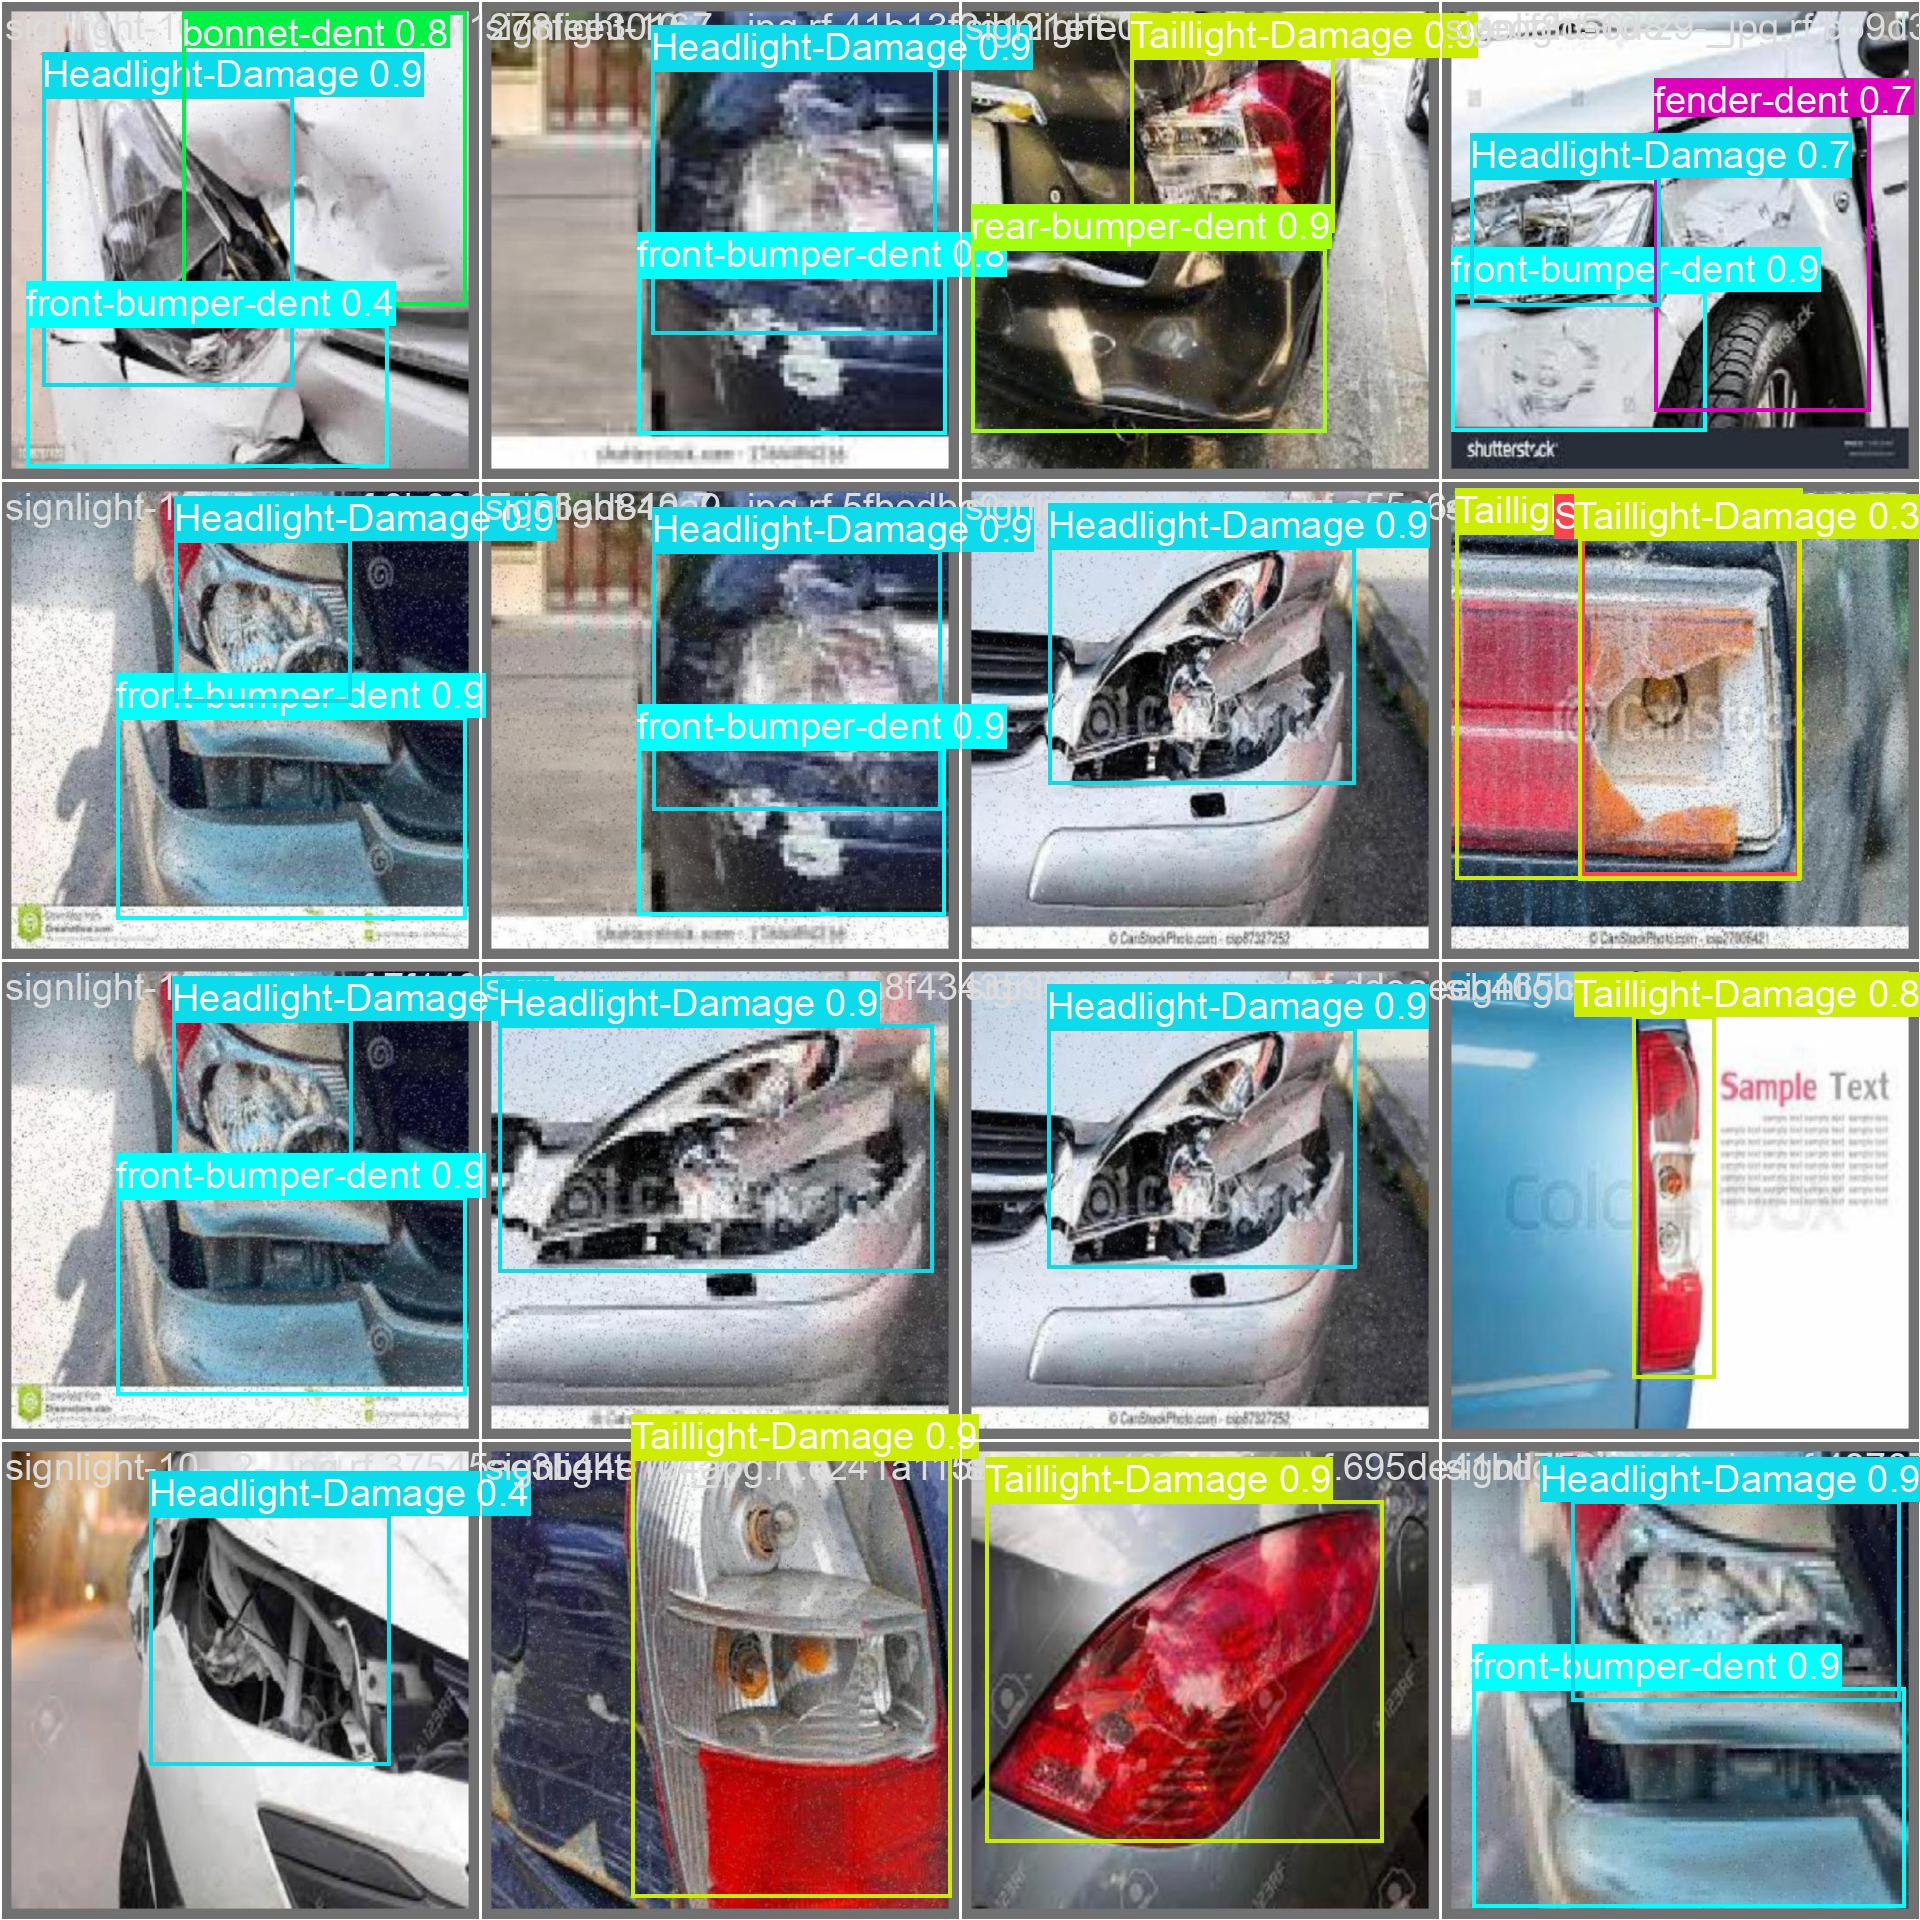

In [ ]:
# Display the model's predictions on the same validation batch
val_predictions_preview_path = os.path.join(TRAINING_OUTPUT_FOLDER, 'val_batch0_pred.jpg')
print('Sample validation batch (model predictions):')
display(Image(filename=val_predictions_preview_path, width=900))

## Step 6 — Run Inference on Test Images and Video

Using `model.predict()` — much cleaner than the old `detect.py` script.

**Key arguments:**
- `source` — image path, folder, video file, webcam index, or URL
- `confidence_threshold` — minimum score to count as a detection (0–1)
- `iou_threshold` — overlap threshold for NMS (Non-Max Suppression)
- `save` — saves annotated outputs to disk

In [ ]:
# ── Inference Settings ────────────────────────────────────────────────
# Minimum confidence score for a detection to be considered valid (0-1)
CONFIDENCE_THRESHOLD = 0.40
# IoU (Intersection over Union) threshold for Non-Maximum Suppression (NMS)
# Detections with IoU above this threshold will be suppressed if they overlap too much
IOU_THRESHOLD        = 0.45
# Image size to use during inference; should ideally match training resolution
INFERENCE_IMAGE_SIZE = 640

# ── Input Sources ─────────────────────────────────────────────────────
# Path to the folder containing test images
TEST_IMAGES_FOLDER = dataset.location + '/test/images'
# Placeholder for a video file path (update if you have a video for inference)
TEST_VIDEO_FILE    = '../video.mp4'

print(f'Confidence threshold : {CONFIDENCE_THRESHOLD}')
print(f'IOU threshold        : {IOU_THRESHOLD}')
print(f'Test images folder   : {TEST_IMAGES_FOLDER}')

Confidence threshold : 0.4
IOU threshold        : 0.45
Test images folder   : /content/Car-Damage-Detection-1/test/images


In [ ]:
# Run inference on all images in the specified test folder
image_inference_results = best_model.predict(
    source    = TEST_IMAGES_FOLDER,      # Source directory containing images
    imgsz     = INFERENCE_IMAGE_SIZE,    # Image size for inference
    conf      = CONFIDENCE_THRESHOLD,    # Confidence threshold for detections
    iou       = IOU_THRESHOLD,           # IoU threshold for NMS
    save      = True,                    # Save annotated images to disk
    save_txt  = True,                    # Also save label .txt files (YOLO format)
    project   = RESULTS_PROJECT_FOLDER,  # Project directory for saving inference results
    name      = 'test_image_predictions',# Name of this inference run
    exist_ok  = True,                    # Allow overwriting if directory exists
)

print(f'\n Inference complete on {len(image_inference_results)} images')

# Print a summary of detections for the first few images
print('First 5 images and their detections:')
for single_image_result in image_inference_results[:5]:
    number_of_detections = len(single_image_result.boxes)
    image_filename = os.path.basename(single_image_result.path)
    print(f'  {image_filename}: {number_of_detections} detection(s)')


image 1/387 /content/Car-Damage-Detection-1/test/images/0118_JPEG_jpg.rf.bb23a97e9adf085fd0c55cd6586e6026.jpg: 640x640 3 RunningBoard-Dents, 16.2ms
image 2/387 /content/Car-Damage-Detection-1/test/images/1-1-_jpeg_jpg.rf.783d845ccc6410644d470b24197a72d8.jpg: 640x640 1 front-bumper-dent, 16.3ms
image 3/387 /content/Car-Damage-Detection-1/test/images/12_jpeg_jpg.rf.610e03eed5ce3628284741e729197415.jpg: 640x640 1 doorouter-dent, 1 quaterpanel-dent, 16.2ms
image 4/387 /content/Car-Damage-Detection-1/test/images/6_jpeg_jpg.rf.cb78f9305dd8a2f6656365dc5848f9f4.jpg: 640x640 1 rear-bumper-dent, 16.3ms
image 5/387 /content/Car-Damage-Detection-1/test/images/9_jpeg_jpg.rf.4e418817bc4b589b8a82d77796b11758.jpg: 640x640 1 Sidemirror-Damage, 16.3ms
image 6/387 /content/Car-Damage-Detection-1/test/images/Bonnet-Dent_jpeg_jpg.rf.47a49185d1d36e14ae381388b8f6e2db.jpg: 640x640 1 bonnet-dent, 16.3ms
image 7/387 /content/Car-Damage-Detection-1/test/images/Fender_jpeg_jpg.rf.660afb184b85a6138cfc077553bc4350

In [ ]:
import glob

# Define the output folder where annotated images from inference were saved
PREDICTIONS_OUTPUT_FOLDER = f'{RESULTS_PROJECT_FOLDER}/test_image_predictions'
# Get paths to the first few predicted images for display
predicted_image_paths = sorted(glob.glob(f'{PREDICTIONS_OUTPUT_FOLDER}/*.jpg'))[:4]

print(f'Sample predictions from the test set ({len(predicted_image_paths)} images shown):')
for predicted_image_path in predicted_image_paths:
    display(Image(filename=predicted_image_path, width=640))

Sample predictions from test set (0 shown):


In [ ]:
"""# Run inference on a video file
# Update TEST_VIDEO_FILE above to point to your video

if os.path.exists(TEST_VIDEO_FILE):
    video_inference_results = best_model.predict(
        source   = TEST_VIDEO_FILE,
        imgsz    = INFERENCE_IMAGE_SIZE,
        conf     = CONFIDENCE_THRESHOLD,
        iou      = IOU_THRESHOLD,
        save     = True,
        project  = RESULTS_PROJECT_FOLDER,
        name     = 'test_video_predictions',
        exist_ok = True,
    )
    print('✅ Video inference complete.')
    print(f'Output saved to: {RESULTS_PROJECT_FOLDER}/test_video_predictions/')
else:
    print(f'⚠️  Video file not found at: {TEST_VIDEO_FILE}')
    print('    Update TEST_VIDEO_FILE path and re-run this cell.') """

"# Run inference on a video file\n# Update TEST_VIDEO_FILE above to point to your video\n\nif os.path.exists(TEST_VIDEO_FILE):\n    video_inference_results = best_model.predict(\n        source   = TEST_VIDEO_FILE,\n        imgsz    = INFERENCE_IMAGE_SIZE,\n        conf     = CONFIDENCE_THRESHOLD,\n        iou      = IOU_THRESHOLD,\n        save     = True,\n        project  = RESULTS_PROJECT_FOLDER,\n        name     = 'test_video_predictions',\n        exist_ok = True,\n    )\n    print('✅ Video inference complete.')\n    print(f'Output saved to: {RESULTS_PROJECT_FOLDER}/test_video_predictions/')\nelse:\n    print(f'⚠️  Video file not found at: {TEST_VIDEO_FILE}')\n    print('    Update TEST_VIDEO_FILE path and re-run this cell.') "

## Step 7 — Export the Trained Model

YOLOv8 can export to many formats for deployment:

| Format | Use case |
|---|---|
| `torchscript` | PyTorch deployment |
| `onnx` | Cross-platform / OpenCV DNN |
| `tflite` | Mobile / edge devices |
| `coreml` | Apple devices |
| `engine` | NVIDIA TensorRT (fastest GPU) |

In [ ]:
EXPORT_FORMAT = 'onnx'   # Change this to 'torchscript', 'tflite', 'coreml', etc. for different deployment targets

# Export the trained YOLOv8 model to the specified format
exported_model_path = best_model.export(
    format = EXPORT_FORMAT,       # Desired export format
    imgsz  = INFERENCE_IMAGE_SIZE, # Image size for the exported model
)

print(f'✅ Model exported to: {exported_model_path}')

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/car_crash_detection_runs/yolov8s_car_damage_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 26, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 343ms
Prepared 4 packages in 4.17s
Installed 4 packages in 322ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 5.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: expo

In [ ]:
# Define the folder where all trained weights and exported models are stored
WEIGHTS_FOLDER = os.path.join(TRAINING_OUTPUT_FOLDER, 'weights')
# Get a list of all files in the weights folder
weight_files = os.listdir(WEIGHTS_FOLDER)

print(f'Saved weights and exported models in {WEIGHTS_FOLDER}:')
for weight_file in weight_files:
    full_path = os.path.join(WEIGHTS_FOLDER, weight_file)
    file_size_mb = os.path.getsize(full_path) / (1024 * 1024) # Convert bytes to MB
    print(f'  {weight_file:20s}  {file_size_mb:.1f} MB')

print(f'\n💡 Use {WEIGHTS_FOLDER}/best.pt for inference (this is the best performing checkpoint on validation data)')
print(f'   Use {WEIGHTS_FOLDER}/last.pt to resume training from the last saved state')
print(f'   The exported model (e.g., {os.path.basename(exported_model_path)}) is ready for deployment')


Saved weights in /content/runs/detect/car_crash_detection_runs/yolov8s_car_damage_v1/weights:
  last.pt               21.5 MB
  best.onnx             42.7 MB
  best.pt               21.5 MB

💡 Use /content/runs/detect/car_crash_detection_runs/yolov8s_car_damage_v1/weights/best.pt for inference (best validation checkpoint)
   Use /content/runs/detect/car_crash_detection_runs/yolov8s_car_damage_v1/weights/last.pt  to resume training


## Bonus — Quick Inference on a Single Image

Once trained, load the model in any Python script like this:

In [ ]:
# ── Load and run inference on any single image ───────────────────────────────

# Load the best trained model (or the exported model if you prefer)
inference_model = YOLO(TRAINED_WEIGHTS_PATH)

# Select an image for quick inference. Uses the first predicted image if available, otherwise the test folder.
single_image_path = predicted_image_paths[0] if predicted_image_paths else TEST_IMAGES_FOLDER

# Run inference on the selected single image
single_image_result = inference_model.predict(
    source = single_image_path,
    conf   = CONFIDENCE_THRESHOLD, # Use the global confidence threshold
    imgsz  = INFERENCE_IMAGE_SIZE, # Use the global inference image size
    save = False,
    show = False,
    verbose = False
)[0]

# Print details of any detected objects
print(f'Image: {os.path.basename(single_image_path)}')
print(f'Detections found: {len(single_image_result.boxes)}')

# Iterate through each detected bounding box and print its details
for detection_box in single_image_result.boxes:
    class_id         = int(detection_box.cls[0])           # Get class ID
    class_label      = class_names[class_id]               # Map ID to class name
    confidence_score = float(detection_box.conf[0])        # Get confidence score
    bounding_box     = detection_box.xyxy[0].tolist()      # Get bounding box coordinates [x1, y1, x2, y2]

    print(f'  Class: {class_label:20s}  Confidence: {confidence_score:.2f}  Box: {[round(v) for v in bounding_box]}')


image 1/387 /content/Car-Damage-Detection-1/test/images/0118_JPEG_jpg.rf.bb23a97e9adf085fd0c55cd6586e6026.jpg: 640x640 3 RunningBoard-Dents, 17.8ms
image 2/387 /content/Car-Damage-Detection-1/test/images/1-1-_jpeg_jpg.rf.783d845ccc6410644d470b24197a72d8.jpg: 640x640 1 front-bumper-dent, 19.0ms
image 3/387 /content/Car-Damage-Detection-1/test/images/12_jpeg_jpg.rf.610e03eed5ce3628284741e729197415.jpg: 640x640 1 doorouter-dent, 1 quaterpanel-dent, 28.5ms
image 4/387 /content/Car-Damage-Detection-1/test/images/6_jpeg_jpg.rf.cb78f9305dd8a2f6656365dc5848f9f4.jpg: 640x640 1 rear-bumper-dent, 18.0ms
image 5/387 /content/Car-Damage-Detection-1/test/images/9_jpeg_jpg.rf.4e418817bc4b589b8a82d77796b11758.jpg: 640x640 1 Sidemirror-Damage, 36.1ms
image 6/387 /content/Car-Damage-Detection-1/test/images/Bonnet-Dent_jpeg_jpg.rf.47a49185d1d36e14ae381388b8f6e2db.jpg: 640x640 1 bonnet-dent, 22.8ms
image 7/387 /content/Car-Damage-Detection-1/test/images/Fender_jpeg_jpg.rf.660afb184b85a6138cfc077553bc4350

In [ ]:
import os

# Install Streamlit
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.5 MB/s eta 0:00:00


In [ ]:
import shutil

# ── Save exported ONNX model to the Streamlit_App directory ──────────────────
# In Google Colab with Google Drive mounted, set this to the Streamlit_App
# folder inside your project on Drive.
# Example: '/content/drive/MyDrive/Car Damage Detection/Streamlit_App'
#
# For local execution, use a path relative to this notebook (in training/):
# STREAMLIT_APP_DIR = '../Streamlit_App'

STREAMLIT_APP_DIR = '/content/drive/MyDrive/Car Damage Detection/Streamlit_App'

os.makedirs(STREAMLIT_APP_DIR, exist_ok=True)

streamlit_model_dest = os.path.join(STREAMLIT_APP_DIR, 'best.onnx')
shutil.copy2(exported_model_path, streamlit_model_dest)

print(f' Model saved to Streamlit_App directory: {streamlit_model_dest}')
print("The 'best.onnx' file is ready to use directly from the Streamlit app.")